# Assignment 1 Part 2

## Part 2a

* Predicting house prices where the relationship between income and house price appears approximately linear
- Linear
- Since the relationship is described as approximately linear, a straight line fit captures the data well. 
* Predicting house prices where house prices increase rapidly for low incomes but level off for high incomes
- Non-linear
- This describe a logarithmic shape which a straight line can't represent, a linear model would either underfit the steep initial rise of the plateau.
* Predicting whether a wine belongs to one of three wine types when straight decision boundaries can separate the classes
- Linear
- Since the classes can already be separated by straight lines, a linear classifier can solve this without needing curved boundaries.
* Predicting whether a student passes an exam where the probability of passing depends strongly on an interaction between study hours and sleep hours
- Non-linear
- There's an interaction effect where study hours depends on the amount of sleep, so the two features interact rather than acting independently. So, a basic linear model can't capture this.
* Predicting the value of y from x, where the relationship follows approximately y = x^2
- Non-linear
- It's a quadratic relationship, a straight line cannot fit a curve that rises at changing the way x^2 does.

## Part 2b

* y = 3x + 5
- Linear
- x is a first power and multiplied by a constant.
* y = x^2 + 2
- Non-linear
- x is squared, which creates a curved relationship between x and y.
* y = log(x)
- Non-linear
- x is inside a logarithmic function, which is not a linear function.
* y = 4x1 − 2x2 + 7
- Linear
- x1 and x2 is a first power.
* y = sin(x)
- Non-linear
- x is inside a sin function, which creates a curve and periodic relationship.

## Part 2c

### Housing Dataset

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing

# as_frame=True returns the 8 features and the target already joined in one DataFrame.
housing = fetch_california_housing(as_frame=True)
df = housing.frame

print(housing.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [4]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
# Correlation between features and the target variable (MedHouseVal)

df.corr()['MedHouseVal'].sort_values(ascending = False)

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64

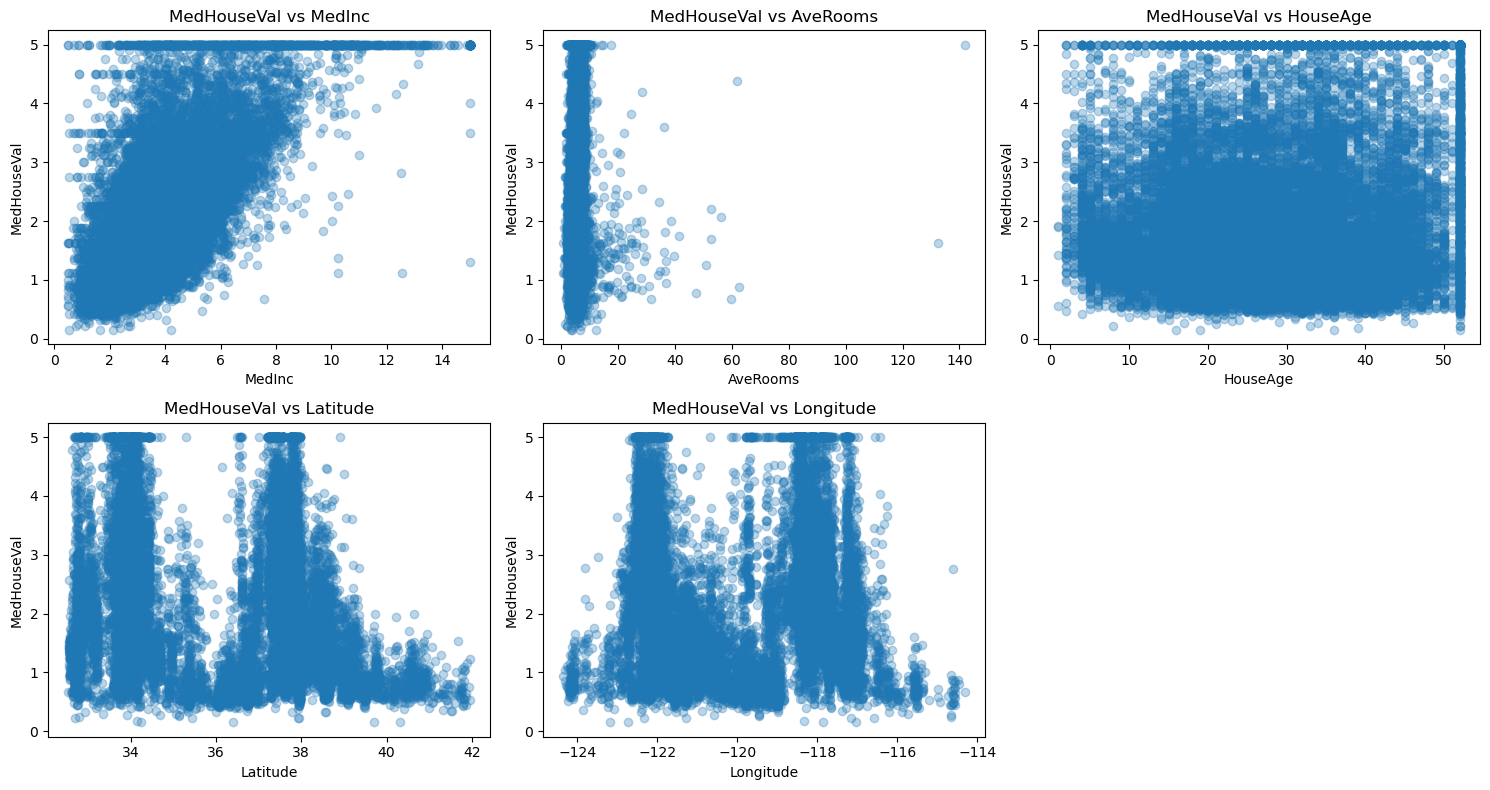

In [ ]:
# Selected features
features = ['MedInc', 'AveRooms', 'HouseAge', 'Latitude', 'Longitude']

# Scatter plots for each selected feature against the target variable 'MedHouseVal'
f, axes = plt.subplots(2, 3, figsize = (15, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    axes[i].scatter(x = df[features[i]], y = df['MedHouseVal'], alpha = 0.3)
    axes[i].set_ylabel('MedHouseVal')
    axes[i].set_xlabel(features[i])
    axes[i].set_title(f'MedHouseVal vs {features[i]}')

f.delaxes(axes[5])

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Decision Tree Regressor with selected features

x_selected = df[features]
y = df['MedHouseVal']

x_train, x_test, y_train, y_test = train_test_split(x_selected, y, test_size = 0.2, random_state = 42)

dectree_selected = DecisionTreeRegressor(random_state = 42)
dectree_selected.fit(x_train, y_train)
pred_selected = dectree_selected.predict(x_test)

print("Selected features:")
print("MSE:", mean_squared_error(y_test, pred_selected))
print("R²:", r2_score(y_test, pred_selected))

Selected features:
MSE: 0.47589086717940887
R²: 0.6368379070339953


In [ ]:
# Decision Tree Regressor with all features 

x = df.drop(columns = 'MedHouseVal')

x_train_all, x_test_all, y_train_all, y_test_all = train_test_split(x, y, test_size = 0.2, random_state = 42)

dectree_selected = DecisionTreeRegressor(random_state = 42)
dectree_selected.fit(x_train_all, y_train_all)
pred_selected = dectree_selected.predict(x_test_all)

print("All features:")
print("MSE:", mean_squared_error(y_test_all, pred_selected))
print("R²:", r2_score(y_test_all, pred_selected))

All features:
MSE: 0.4997071473927568
R²: 0.6186632145457622


The selected features model (MedInc, AveRooms, HouseAge, Latitude, Longitude) produced a lower MSE (0.476 vs 0.500) and a higher R2 (0.637 vs 0.619) than compared to the models with all 8 features. 

This suggests that the excluded features (AveBedrms, Population, and AveOccup) contributed mostly noise rather than useful signal, and that the nonlinear relationship visible in the Latitude and Longitude scatter plots was well captured by the decision tree using the selected features alone. 

In [ ]:
# Checking for negative values in Latitude and Longitude

print(df['Latitude'].min(), df['Latitude'].max())
print(df['Longitude'].min(), df['Longitude'].max())

32.54 41.95
-124.35 -114.31


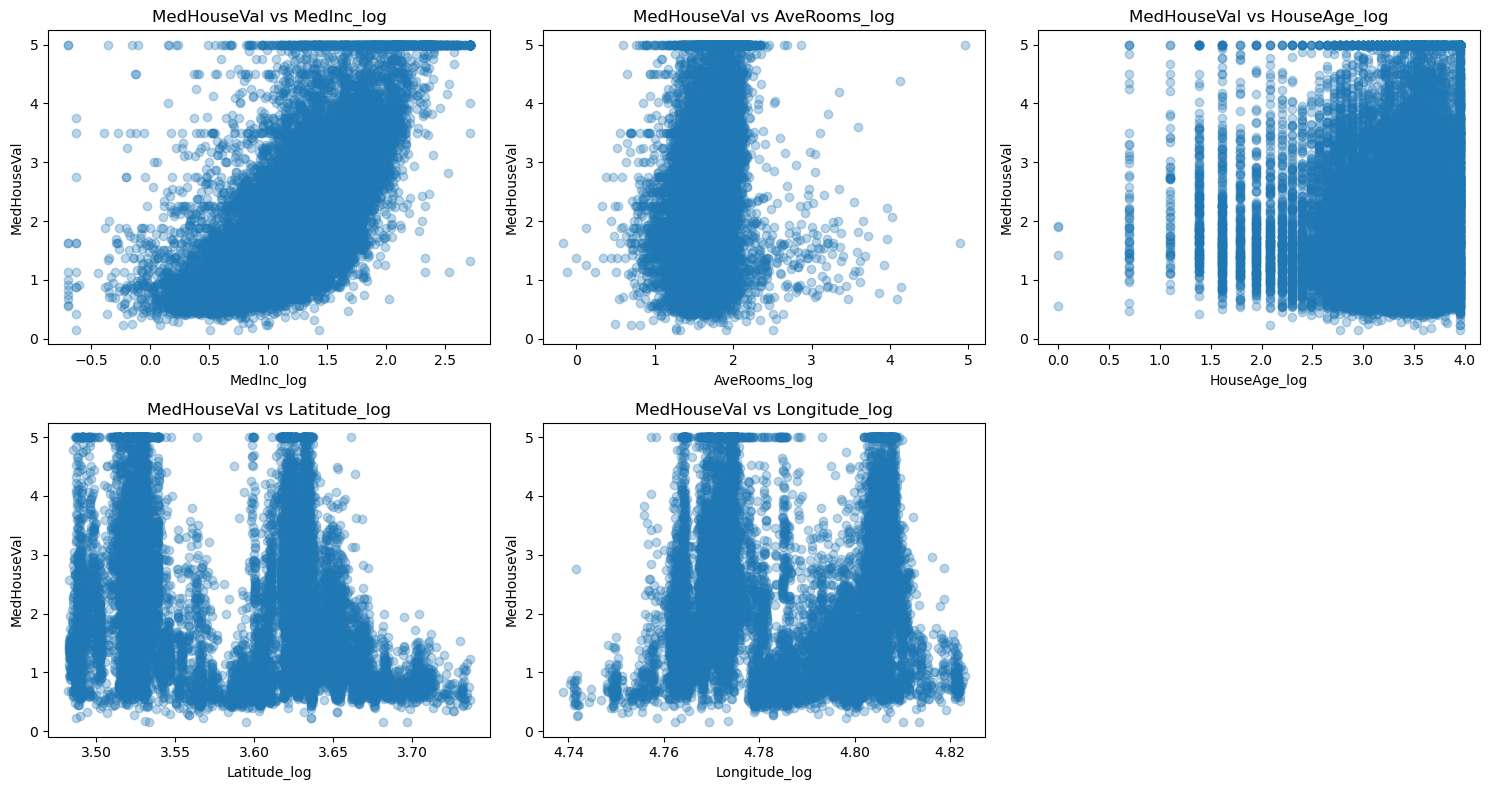

In [ ]:
# Log transformation of features

transformed_features_log = {}

for feature in features:
    if feature == 'Longitude':
        transformed_features_log[f'{feature}_log'] = np.log(np.abs(df[feature]))
    else:
        transformed_features_log[f'{feature}_log'] = np.log(df[feature])

f, axes = plt.subplots(2, 3, figsize = (15, 8))
axes = axes.flatten()

for i, (feature, values) in enumerate(transformed_features_log.items()):
    axes[i].scatter(values, df['MedHouseVal'], alpha = 0.3)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('MedHouseVal')
    axes[i].set_title(f'MedHouseVal vs {feature}')

f.delaxes(axes[5])

plt.tight_layout()
plt.show()

In [ ]:
# Comparison of correlation before and after log transformation

for feature in features:
    if feature == 'Longitude':
        log_corr = np.log(np.abs(df[feature])).corr(df['MedHouseVal'])
    else:
        log_corr = np.log(df[feature]).corr(df['MedHouseVal'])
    
    original_corr = df[feature].corr(df['MedHouseVal'])
    
    print(feature, "-> original:", round(original_corr, 3), "| log:", round(log_corr, 3))

MedInc -> original: 0.688 | log: 0.652
AveRooms -> original: 0.152 | log: 0.24
HouseAge -> original: 0.106 | log: 0.076
Latitude -> original: -0.144 | log: -0.141
Longitude -> original: -0.046 | log: 0.046


Transformed MedInc (MedInc_log) is approximately linear. Its correlation with MedHouseVal is 0.652, slightly lower than the original MedInc's correlation of 0.688. This slight decrease indicates the log transformation did not improve linearity. MedInc already had a fairly linear relationship with the target, and the transformation was not needed.

Transformed AveRooms (AveRooms_log) is more linear than before, though still fairly weak. Its correlation increased from 0.152 to 0.240 after the log transformation.

Transformed HouseAge (HouseAge_log) shows no meaningful relationship (neither linear nor nonlinear). Its correlation decreased from 0.106 to 0.076. Both scatter plots from before and after the transformation show a flat, scattered cloud with no discernible pattern. 

Transformed Latitude (Latitude_log) is nonlinear. Its correlation remains weak and barely changed from -0.144 to -0.141. The scatter plot continues to show a clustered pattern with several distinct peaks. 

Transformed Longitude (Longitude_log) is nonlinear. Its correlation remains weak, changing from -0.046 to 0.046 (the sign flip is due to taking the absolute value of Longitude before applying the log, since Longitude values are negative). The scatter plot shows a similar clustered pattern with several distinct peaks as Latitude.